In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("azure_ts_24m_clean.csv")


In [4]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (1152, 8)

Columns:
 Index(['timestamp', 'region', 'service_type', 'demand_units',
       'capacity_allocated', 'cost_usd', 'availability_pct',
       'customer_growth_rate'],
      dtype='object')

Missing Values:
 timestamp               0
region                  0
service_type            0
demand_units            0
capacity_allocated      0
cost_usd                0
availability_pct        0
customer_growth_rate    0
dtype: int64


,timestamp,region,service_type,demand_units,capacity_allocated,cost_usd,availability_pct,customer_growth_rate
0,2023-01-01,East US,Compute,428.0,570,1397.99,99.47,0.999
1,2023-01-01,West Europe,Compute,294.0,630,988.87,99.13,0.997
2,2023-01-01,Central India,Compute,229.0,608,1754.86,99.77,1.005
3,2023-01-01,Southeast Asia,Storage,356.0,460,756.36,99.38,1.032
4,2023-01-02,Central India,Compute,332.0,479,614.02,99.18,1.038


In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(df.dtypes)

timestamp               datetime64[ns]
region                          object
service_type                    object
demand_units                   float64
capacity_allocated               int64
cost_usd                       float64
availability_pct               float64
customer_growth_rate           float64
dtype: object


In [6]:
print(df['timestamp'].min())
print(df['timestamp'].max())

print("\nUnique time difference values:")
print(df['timestamp'].sort_values().diff().value_counts().head())

2023-01-01 00:00:00
2024-12-12 00:00:00

Unique time difference values:
timestamp
0 days     864
1 days     264
20 days     13
19 days      8
17 days      1
Name: count, dtype: int64


In [7]:
df = df.sort_values('timestamp')
df = df.reset_index(drop=True)

df.head()

,timestamp,region,service_type,demand_units,capacity_allocated,cost_usd,availability_pct,customer_growth_rate
0,2023-01-01,East US,Compute,428.0,570,1397.99,99.47,0.999
1,2023-01-01,West Europe,Compute,294.0,630,988.87,99.13,0.997
2,2023-01-01,Central India,Compute,229.0,608,1754.86,99.77,1.005
3,2023-01-01,Southeast Asia,Storage,356.0,460,756.36,99.38,1.032
4,2023-01-02,Central India,Compute,332.0,479,614.02,99.18,1.038


In [8]:
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

df.head()

,timestamp,region,service_type,demand_units,capacity_allocated,cost_usd,availability_pct,customer_growth_rate,year,month,day,day_of_week,is_weekend
0,2023-01-01,East US,Compute,428.0,570,1397.99,99.47,0.999,2023,1,1,6,1
1,2023-01-01,West Europe,Compute,294.0,630,988.87,99.13,0.997,2023,1,1,6,1
2,2023-01-01,Central India,Compute,229.0,608,1754.86,99.77,1.005,2023,1,1,6,1
3,2023-01-01,Southeast Asia,Storage,356.0,460,756.36,99.38,1.032,2023,1,1,6,1
4,2023-01-02,Central India,Compute,332.0,479,614.02,99.18,1.038,2023,1,2,0,0


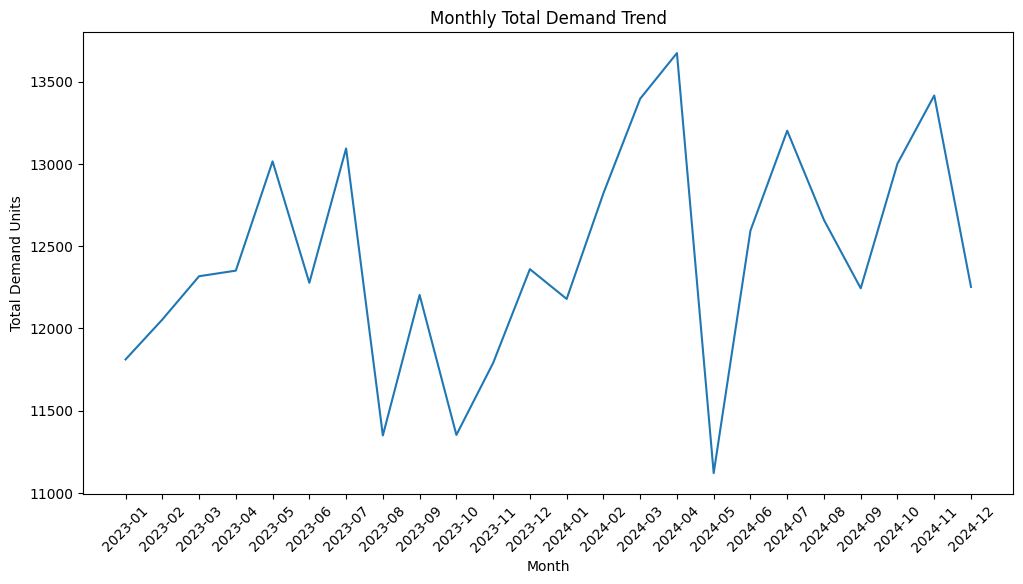

In [10]:
# Create year-month column
df['year_month'] = df['timestamp'].dt.to_period('M')

# Aggregate monthly demand
monthly_demand = df.groupby('year_month')['demand_units'].sum().reset_index()

# Convert back to timestamp for plotting
monthly_demand['year_month'] = monthly_demand['year_month'].astype(str)

# Plot
plt.figure(figsize=(12,6))
plt.plot(monthly_demand['year_month'], monthly_demand['demand_units'])
plt.title("Monthly Total Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Demand Units")
plt.xticks(rotation=45)
plt.show()

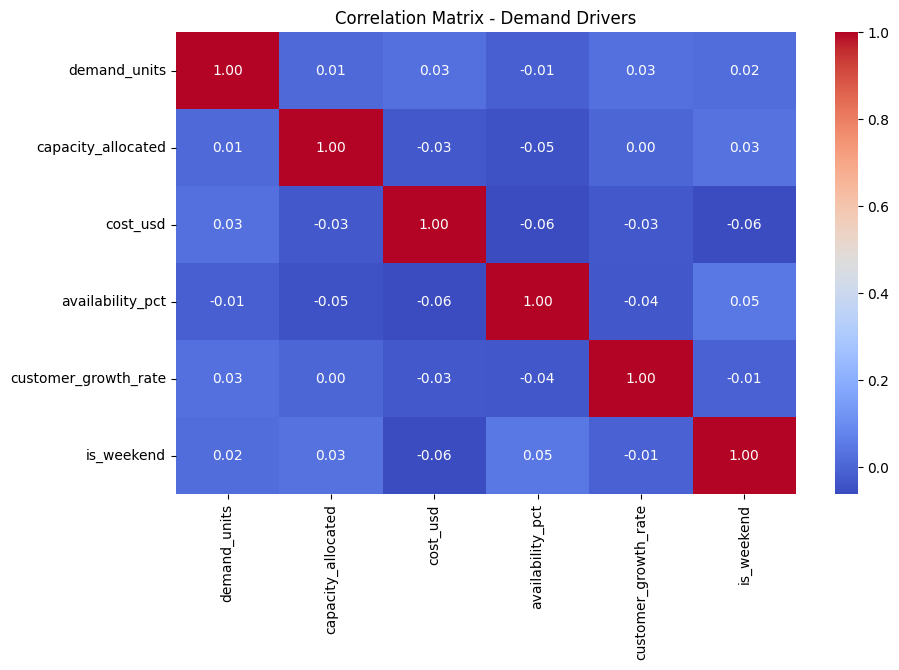

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix - Demand Drivers")
plt.show()

In [13]:
df = df.sort_values(['region', 'service_type', 'timestamp'])

df['lag_1'] = df.groupby(['region','service_type'])['demand_units'].shift(1)
df['lag_7'] = df.groupby(['region','service_type'])['demand_units'].shift(7)

df.head(10)

,timestamp,region,service_type,demand_units,capacity_allocated,cost_usd,availability_pct,customer_growth_rate,year,month,day,day_of_week,is_weekend,year_month,lag_1,lag_7
2,2023-01-01,Central India,Compute,229.0,608,1754.86,99.77,1.005,2023,1,1,6,1,2023-01,NaN,NaN
4,2023-01-02,Central India,Compute,332.0,479,614.02,99.18,1.038,2023,1,2,0,0,2023-01,229.0,NaN
11,2023-01-03,Central India,Compute,125.0,454,1771.78,99.52,1.011,2023,1,3,1,0,2023-01,332.0,NaN
16,2023-01-05,Central India,Compute,201.0,329,969.63,99.73,1.079,2023,1,5,3,0,2023-01,125.0,NaN
24,2023-01-07,Central India,Compute,127.0,317,484.85,99.60,1.030,2023,1,7,5,1,2023-01,201.0,NaN
38,2023-01-10,Central India,Compute,245.0,610,373.94,99.20,1.022,2023,1,10,1,0,2023-01,127.0,NaN
47,2023-01-12,Central India,Compute,101.0,387,1185.26,99.25,1.004,2023,1,12,3,0,2023-01,245.0,NaN
51,2023-02-01,Central India,Compute,386.0,434,555.79,98.78,1.094,2023,2,1,2,0,2023-02,101.0,229.0
52,2023-02-02,Central India,Compute,107.0,501,1145.95,99.78,0.991,2023,2,2,3,0,2023-02,386.0,332.0
57,2023-02-03,Central India,Compute,264.5,321,1231.37,98.76,1.085,2023,2,3,4,0,2023-02,107.0,125.0


In [14]:
print("Before dropping NaNs:", df.shape)

df = df.dropna()

print("After dropping NaNs:", df.shape)

df.isnull().sum()

Before dropping NaNs: (1152, 16)
After dropping NaNs: (1096, 16)


,0
timestamp,0
region,0
service_type,0
demand_units,0
capacity_allocated,0
cost_usd,0
availability_pct,0
customer_growth_rate,0
year,0
month,0


In [15]:
df['rolling_mean_7'] = (
    df.groupby(['region','service_type'])['demand_units']
    .transform(lambda x: x.rolling(7).mean())
)

df.head(10)

,timestamp,region,service_type,demand_units,capacity_allocated,cost_usd,availability_pct,customer_growth_rate,year,month,day,day_of_week,is_weekend,year_month,lag_1,lag_7,rolling_mean_7
51,2023-02-01,Central India,Compute,386.0,434,555.79,98.78,1.094,2023,2,1,2,0,2023-02,101.0,229.0,NaN
52,2023-02-02,Central India,Compute,107.0,501,1145.95,99.78,0.991,2023,2,2,3,0,2023-02,386.0,332.0,NaN
57,2023-02-03,Central India,Compute,264.5,321,1231.37,98.76,1.085,2023,2,3,4,0,2023-02,107.0,125.0,NaN
71,2023-02-06,Central India,Compute,258.0,509,671.27,98.91,1.002,2023,2,6,0,0,2023-02,264.5,201.0,NaN
73,2023-02-07,Central India,Compute,301.0,430,574.26,99.77,1.014,2023,2,7,1,0,2023-02,258.0,127.0,NaN
83,2023-02-09,Central India,Compute,102.0,634,1730.45,99.15,0.985,2023,2,9,3,0,2023-02,301.0,245.0,NaN
87,2023-02-10,Central India,Compute,198.0,461,396.14,99.47,1.069,2023,2,10,4,0,2023-02,102.0,101.0,230.928571
89,2023-02-11,Central India,Compute,108.0,450,378.00,99.45,0.989,2023,2,11,5,1,2023-02,198.0,386.0,191.214286
106,2023-03-03,Central India,Compute,118.0,570,1492.21,99.59,1.006,2023,3,3,4,0,2023-03,108.0,107.0,192.785714
109,2023-03-04,Central India,Compute,449.0,565,1571.50,99.08,1.098,2023,3,4,5,1,2023-03,118.0,264.5,219.142857


In [16]:
print("Before dropping rolling NaNs:", df.shape)

df = df.dropna()

print("After dropping rolling NaNs:", df.shape)

df.isnull().sum()

Before dropping rolling NaNs: (1096, 17)
After dropping rolling NaNs: (1048, 17)


,0
timestamp,0
region,0
service_type,0
demand_units,0
capacity_allocated,0
cost_usd,0
availability_pct,0
customer_growth_rate,0
year,0
month,0


In [17]:
# Calculate mean and std per group
group_stats = df.groupby(['region','service_type'])['demand_units'].agg(['mean','std']).reset_index()

# Merge back to main dataframe
df = df.merge(group_stats, on=['region','service_type'], how='left')

# Create spike flag (2 standard deviations rule)
df['demand_spike'] = (
    df['demand_units'] > (df['mean'] + 2 * df['std'])
).astype(int)

df.head()

,timestamp,region,service_type,demand_units,capacity_allocated,cost_usd,availability_pct,customer_growth_rate,year,month,day,day_of_week,is_weekend,year_month,lag_1,lag_7,rolling_mean_7,mean,std,demand_spike
0,2023-02-10,Central India,Compute,198.0,461,396.14,99.47,1.069,2023,2,10,4,0,2023-02,102.0,101.0,230.928571,257.229508,108.002892,0
1,2023-02-11,Central India,Compute,108.0,450,378.00,99.45,0.989,2023,2,11,5,1,2023-02,198.0,386.0,191.214286,257.229508,108.002892,0
2,2023-03-03,Central India,Compute,118.0,570,1492.21,99.59,1.006,2023,3,3,4,0,2023-03,108.0,107.0,192.785714,257.229508,108.002892,0
3,2023-03-04,Central India,Compute,449.0,565,1571.50,99.08,1.098,2023,3,4,5,1,2023-03,118.0,264.5,219.142857,257.229508,108.002892,0
4,2023-03-05,Central India,Compute,442.0,533,893.15,99.10,0.998,2023,3,5,6,1,2023-03,449.0,258.0,245.428571,257.229508,108.002892,0


In [18]:
df['demand_spike'] = (
    df['demand_units'] > (df['mean'] + 1.5 * df['std'])
).astype(int)

df['demand_spike'].value_counts()

,count
demand_spike,
0,983
1,65


In [19]:
df = df.drop(columns=['mean','std'])

print(df.shape)
df.head()

(1048, 18)


,timestamp,region,service_type,demand_units,capacity_allocated,cost_usd,availability_pct,customer_growth_rate,year,month,day,day_of_week,is_weekend,year_month,lag_1,lag_7,rolling_mean_7,demand_spike
0,2023-02-10,Central India,Compute,198.0,461,396.14,99.47,1.069,2023,2,10,4,0,2023-02,102.0,101.0,230.928571,0
1,2023-02-11,Central India,Compute,108.0,450,378.00,99.45,0.989,2023,2,11,5,1,2023-02,198.0,386.0,191.214286,0
2,2023-03-03,Central India,Compute,118.0,570,1492.21,99.59,1.006,2023,3,3,4,0,2023-03,108.0,107.0,192.785714,0
3,2023-03-04,Central India,Compute,449.0,565,1571.50,99.08,1.098,2023,3,4,5,1,2023-03,118.0,264.5,219.142857,1
4,2023-03-05,Central India,Compute,442.0,533,893.15,99.10,0.998,2023,3,5,6,1,2023-03,449.0,258.0,245.428571,1


In [20]:
print(df[['region','service_type']].head())

          region service_type
0  Central India      Compute
1  Central India      Compute
2  Central India      Compute
3  Central India      Compute
4  Central India      Compute


In [21]:
# One-hot encode categorical columns
df = pd.get_dummies(df, columns=['region', 'service_type'], drop_first=True)

print(df.shape)
df.head()

(1048, 20)


,timestamp,demand_units,capacity_allocated,cost_usd,availability_pct,customer_growth_rate,year,month,day,day_of_week,is_weekend,year_month,lag_1,lag_7,rolling_mean_7,demand_spike,region_East US,region_Southeast Asia,region_West Europe,service_type_Storage
0,2023-02-10,198.0,461,396.14,99.47,1.069,2023,2,10,4,0,2023-02,102.0,101.0,230.928571,0,False,False,False,False
1,2023-02-11,108.0,450,378.00,99.45,0.989,2023,2,11,5,1,2023-02,198.0,386.0,191.214286,0,False,False,False,False
2,2023-03-03,118.0,570,1492.21,99.59,1.006,2023,3,3,4,0,2023-03,108.0,107.0,192.785714,0,False,False,False,False
3,2023-03-04,449.0,565,1571.50,99.08,1.098,2023,3,4,5,1,2023-03,118.0,264.5,219.142857,1,False,False,False,False
4,2023-03-05,442.0,533,893.15,99.10,0.998,2023,3,5,6,1,2023-03,449.0,258.0,245.428571,1,False,False,False,False


In [22]:
print(df.dtypes)

timestamp                datetime64[ns]
demand_units                    float64
capacity_allocated                int64
cost_usd                        float64
availability_pct                float64
customer_growth_rate            float64
year                              int32
month                             int32
day                               int32
day_of_week                       int32
is_weekend                        int64
year_month                    period[M]
lag_1                           float64
lag_7                           float64
rolling_mean_7                  float64
demand_spike                      int64
region_East US                     bool
region_Southeast Asia              bool
region_West Europe                 bool
service_type_Storage               bool
dtype: object


In [24]:
df = df.drop(columns=['timestamp', 'year_month'])

In [25]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(df.dtypes)
print("Final Shape:", df.shape)

demand_units             float64
capacity_allocated         int64
cost_usd                 float64
availability_pct         float64
customer_growth_rate     float64
year                       int32
month                      int32
day                        int32
day_of_week                int32
is_weekend                 int64
lag_1                    float64
lag_7                    float64
rolling_mean_7           float64
demand_spike               int64
region_East US             int64
region_Southeast Asia      int64
region_West Europe         int64
service_type_Storage       int64
dtype: object
Final Shape: (1048, 18)


In [27]:
df.to_csv("Milestone2_ModelReady.csv", index=False)

In [28]:
import os
os.getcwd()

'/content'

In [29]:
from google.colab import files
files.download("Milestone2_ModelReady.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>